# Healthcare Accessibility in Casablanca: Geospatial Capstone Analysis

## 1. Introduction and Research Question

Access to healthcare is a core dimension of urban equity. In large metropolitan areas such as Casablanca, physical proximity to facilities does not always imply practical access, especially when population concentration, transport infrastructure, and spatial form vary across districts.

This notebook investigates the research question:
**How accessible are healthcare services to the population in Casablanca, and which areas are underserved?**

### Study Objective
- Quantify spatial accessibility to healthcare services across Casablanca.
- Detect geographic disparities between service supply and population demand.
- Identify potentially underserved areas to support evidence-based planning decisions.

### Datasets Used
- Healthcare facilities: point locations of hospitals and clinics.
- Transport stops: bus and tram stops, including mode and route information.
- Administrative boundaries: districts/communes used for aggregation and comparison.
- Population distribution: district-level population attributes and geometries.

### Why This Matters
The analysis supports public health and urban planning by highlighting where residents may face longer travel burdens to reach care. Results can inform priorities for new facilities, improved transit connectivity, and equitable service allocation.

In [1]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
PROCESSED_DIR = f"{DATA_DIR}/processed"
ANALYSIS_OUTPUT_DIR = f"{DATA_DIR}/analysis"


HEALTHCARE_PATH = f"{PROCESSED_DIR}/Casablanca_Healthcare.gpkg"
TRANSPORT_PATH = f"{PROCESSED_DIR}/Casablanca_Transport_Stops.gpkg"
DISTRICTS_PATH = f"{PROCESSED_DIR}/Casablanca_Districts.gpkg"
POPULATION_PATH = f"{PROCESSED_DIR}/population_by_districts.gpkg"

CRS_METRIC      = "EPSG:26191"   # Morocco zone 1 (metres) — for accurate distance
CRS_GEO         = "EPSG:4326"    # WGS84 for web maps

import os
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
import folium
from sklearn.neighbors import NearestNeighbors
from folium.plugins import MarkerCluster, HeatMap
import ast
import matplotlib.patheffects as pe
from matplotlib.ticker import FuncFormatter
from shapely.geometry import Point, LineString, Polygon
import networkx as nx


## 2. Data Ingestion

This section loads the four core geospatial layers and confirms row counts and coordinate reference systems (CRS).
A reliable analysis requires consistent schema and geometry metadata before any spatial operation.

In [3]:
# Load files
hospitals = gpd.read_file(HEALTHCARE_PATH)
stops = gpd.read_file(TRANSPORT_PATH)
districts = gpd.read_file(DISTRICTS_PATH)
population = gpd.read_file(POPULATION_PATH)


print(f'Healthcare facilities : {len(hospitals):,} rows | CRS: {hospitals.crs}')
print(f'Transport stops       : {len(stops):,}  rows | CRS: {stops.crs}')
print(f'Districts             : {len(districts):,}  rows | CRS: {districts.crs}')
print(f'Population            : {len(population):,}  rows | CRS: {population.crs}')

Healthcare facilities : 84 rows | CRS: EPSG:4326
Transport stops       : 1,463  rows | CRS: EPSG:4326
Districts             : 34  rows | CRS: EPSG:4326
Population            : 34  rows | CRS: EPSG:4326


## 3. Data Preparation and Standardization

Before analysis, datasets are harmonized to a common spatial reference and key attributes are parsed into analysis-ready formats.
This step is essential to avoid distance distortions and inconsistent joins.

### 3.1 CRS Harmonization and Attribute Parsing

**Why CRS transformation matters:**

Distance and area calculations are only meaningful in a projected coordinate system with meter units.
This notebook uses `EPSG:3857` to standardize spatial operations across layers. While convenient and commonly used, it can introduce mild distance distortion; therefore, results should be interpreted as planning-grade approximations.

**What is done here:**
- Reproject healthcare, transport, district, and population layers to a shared CRS.
- Parse transport `mode` and `Lines` fields from string-like lists into usable Python lists.
- Derive operational features (`primary_mode`, `num_lines`) for later service characterization.

In [4]:
# Reproject to metric CRS for distance calculations
hospitals = hospitals.to_crs(epsg=3857)
stops  = stops.to_crs(epsg=3857)
districts = districts.to_crs(epsg=3857)
population = population.to_crs(epsg=3857)

In [5]:
# Parse transport mode & lines columns which are stored as strings like "['casabus', 'tram']"
def safe_parse_list(val):
    """Safely parse a string like "['casabus', 'tram']" into a Python list"""
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else [result]
    except:
        return [str(val)]

stops['mode_list']  = stops['mode'].apply(safe_parse_list)
stops['lines_list'] = stops['Lines'].apply(safe_parse_list)

# Primary mode (first element)
stops['primary_mode'] = stops['mode_list'].apply(lambda x: x[0] if x else 'unknown')
stops['num_lines']    = stops['lines_list'].apply(len)

print('Transport modes:')
print(stops['mode'].value_counts())

print('Primary Transport modes:')
print(stops['primary_mode'].value_counts())

print(f'\nAvg lines per stop: {stops["num_lines"].mean():.2f}')

Transport modes:
mode
['casabus']              1311
['tram']                   96
['busway']                 41
['tram', 'casabus']         8
['casabus', 'tram']         6
['busway', 'casabus']       1
Name: count, dtype: int64
Primary Transport modes:
primary_mode
casabus    1317
tram        104
busway       42
Name: count, dtype: int64

Avg lines per stop: 1.97


In [6]:
# Create district centroids for origin points
districts['centroid'] = districts.geometry.centroid
districts['centroid_x'] = districts.centroid.x
districts['centroid_y'] = districts.centroid.y

# Calculate district area in km²
districts['area_km2'] = districts.geometry.area / 1_000_000

print("✓ District centroids created")
print(f"Total study area: {districts['area_km2'].sum():.2f} km²")

✓ District centroids created
Total study area: 1208.62 km²


## 4. Exploratory Data Analysis (EDA)

The EDA phase establishes baseline patterns in service distribution and demographic concentration.
Each visualization is interpreted in terms of urban structure, centrality, and potential inequality in healthcare access.

In [7]:
# Quick peek at each dataset
print('=== HEALTHCARE ===')
display(hospitals.head(2))
print('\n=== TRANSPORT STOPS ===')
display(stops.head(2))
print('\n=== DISTRICTS ===')
display(districts.head(2))
print('\n=== POPULATION ===')
display(population.head(2))

=== HEALTHCARE ===


,name,latitude,longitude,geometry
0,clinique badr,33.594870,-7.641098,POINT (-850603.15 3974531.788)
1,hôpital sidi othmane,33.558542,-7.573301,POINT (-843055.989 3969677.974)



=== TRANSPORT STOPS ===


,cluster_id,stop_name,Lines,mode,longitude,latitude,geometry,mode_list,lines_list,primary_mode,num_lines
0,0,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633955,33.592059,POINT (-849807.939 3974156.154),[casabus],"[L09E, L084, L050, L013]",casabus,4
1,1,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633524,33.592137,POINT (-849760.016 3974166.578),[casabus],"[L09E, L084, L050, L013]",casabus,4



=== DISTRICTS ===


,district,commune,commune_type_encoded,geometry,centroid,centroid_x,centroid_y,area_km2
0,Bouskoura,Bouskoura,0,"MULTIPOLYGON (((-855815.032 3950215.122, -8558...",POINT (-850558.96 3957111.367),-850558.960491,3.957111e+06,165.287114
1,Bouskoura,Dar Bouazza,0,"MULTIPOLYGON (((-864600.99 3956366.796, -86544...",POINT (-865489.297 3962742.471),-865489.296568,3.962742e+06,216.995776



=== POPULATION ===


,commune,population,geometry
0,tit mellil,56019,"MULTIPOLYGON (((-833696.916 3965256.855, -8347..."
1,mediouna,29972,"MULTIPOLYGON (((-837515.211 3955366.144, -8374..."


In [8]:
# Data types and null counts
print('--- Healthcare info ---')
hospitals.info()
print('\n--- Stops info ---')
stops.info()
print('\n--- Districts info ---')
districts.info()
print('\n--- Population info ---')
population.info()

--- Healthcare info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   name       84 non-null     object  
 1   latitude   84 non-null     float64 
 2   longitude  84 non-null     float64 
 3   geometry   84 non-null     geometry
dtypes: float64(2), geometry(1), object(1)
memory usage: 2.8+ KB

--- Stops info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cluster_id    1463 non-null   int64   
 1   stop_name     1463 non-null   object  
 2   Lines         1463 non-null   object  
 3   mode          1463 non-null   object  
 4   longitude     1463 non-null   float64 
 5   latitude      1463 non-null   float64 
 6   geometry      1463 non-null   geometry
 7   mode_list     1463 

### 4.1 Spatial Validation and Coverage Diagnostics

Before interpreting access, we verify that layers occupy the same geographic extent and that point patterns align with district boundaries.


In [9]:
# ── Geographic extent / bounding box comparison ──────────────────────────
print('Healthcare bounding box:')
print(f'  Lat: {hospitals.latitude.min():.4f} → {hospitals.latitude.max():.4f}')
print(f'  Lon: {hospitals.longitude.min():.4f} → {hospitals.longitude.max():.4f}')

print('\nTransport bounding box:')
print(f'  Lat: {stops.latitude.min():.4f} → {stops.latitude.max():.4f}')
print(f'  Lon: {stops.longitude.min():.4f} → {stops.longitude.max():.4f}')

Healthcare bounding box:
  Lat: 33.4942 → 33.6401
  Lon: -7.7327 → -7.4488

Transport bounding box:
  Lat: 33.3717 → 33.7088
  Lon: -7.8853 → -7.3305


Comparable bounding extents indicate that healthcare and transport datasets likely describe the same urban system.

#### Distribution of healthcare facilities and transport stops

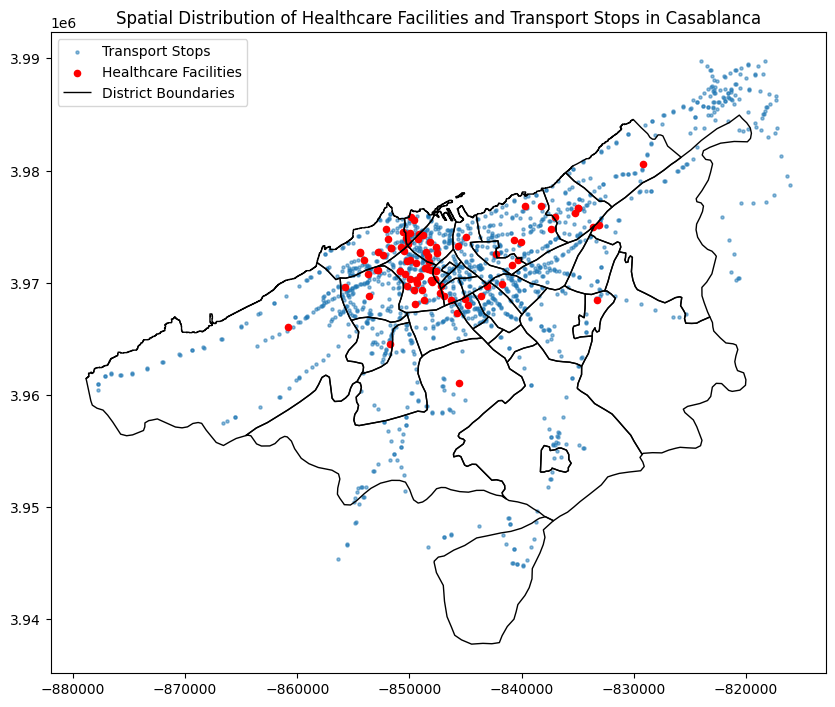

In [10]:
fig, ax = plt.subplots(figsize=(10,10))

stops.plot(ax=ax, markersize=5, alpha=0.5, label="Transport Stops")
hospitals.plot(ax=ax, color="red", markersize=20, label="Healthcare Facilities")
districts.boundary.plot(ax=ax, color="black", linewidth=1, label="District Boundaries")

plt.legend()
plt.title("Spatial Distribution of Healthcare Facilities and Transport Stops in Casablanca")
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/SpatialVisualization.png', bbox_inches='tight')
plt.show()

This map provides a first visual test of service geography. Healthcare points are concentrated in central districts while peripheral areas show sparse facility coverage.

### Transport mode distribution

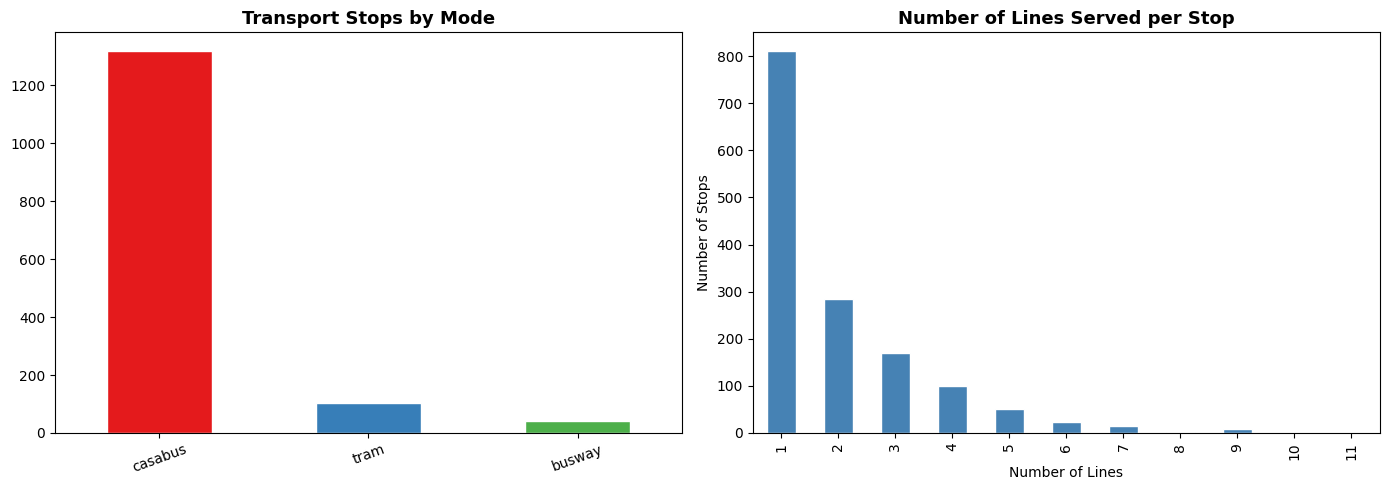


Summary:
  Stops with only 1 line : 810 (55.4%)
  Stops with 3+ lines    : 368 (25.2%)


In [11]:
# ── Transport mode distribution & lines per stop ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode counts
mode_counts = stops['primary_mode'].value_counts()
mode_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set1'), edgecolor='white')
axes[0].set_title('Transport Stops by Mode', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Lines per stop
stops['num_lines'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Number of Lines Served per Stop', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Lines')
axes[1].set_ylabel('Number of Stops')

plt.tight_layout()
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/transport_eda.png', bbox_inches='tight')
plt.show()

print(f'\nSummary:')
print(f'  Stops with only 1 line : {(stops["num_lines"]==1).sum()} ({(stops["num_lines"]==1).mean()*100:.1f}%)')
print(f'  Stops with 3+ lines    : {(stops["num_lines"]>=3).sum()} ({(stops["num_lines"]>=3).mean()*100:.1f}%)')

The results indicate a clear spatial imbalance in transport provision across Casablanca. The network is strongly bus-dominant relative to tram, so rail-based accessibility is structurally limited to fewer corridors.


# Population Density per District

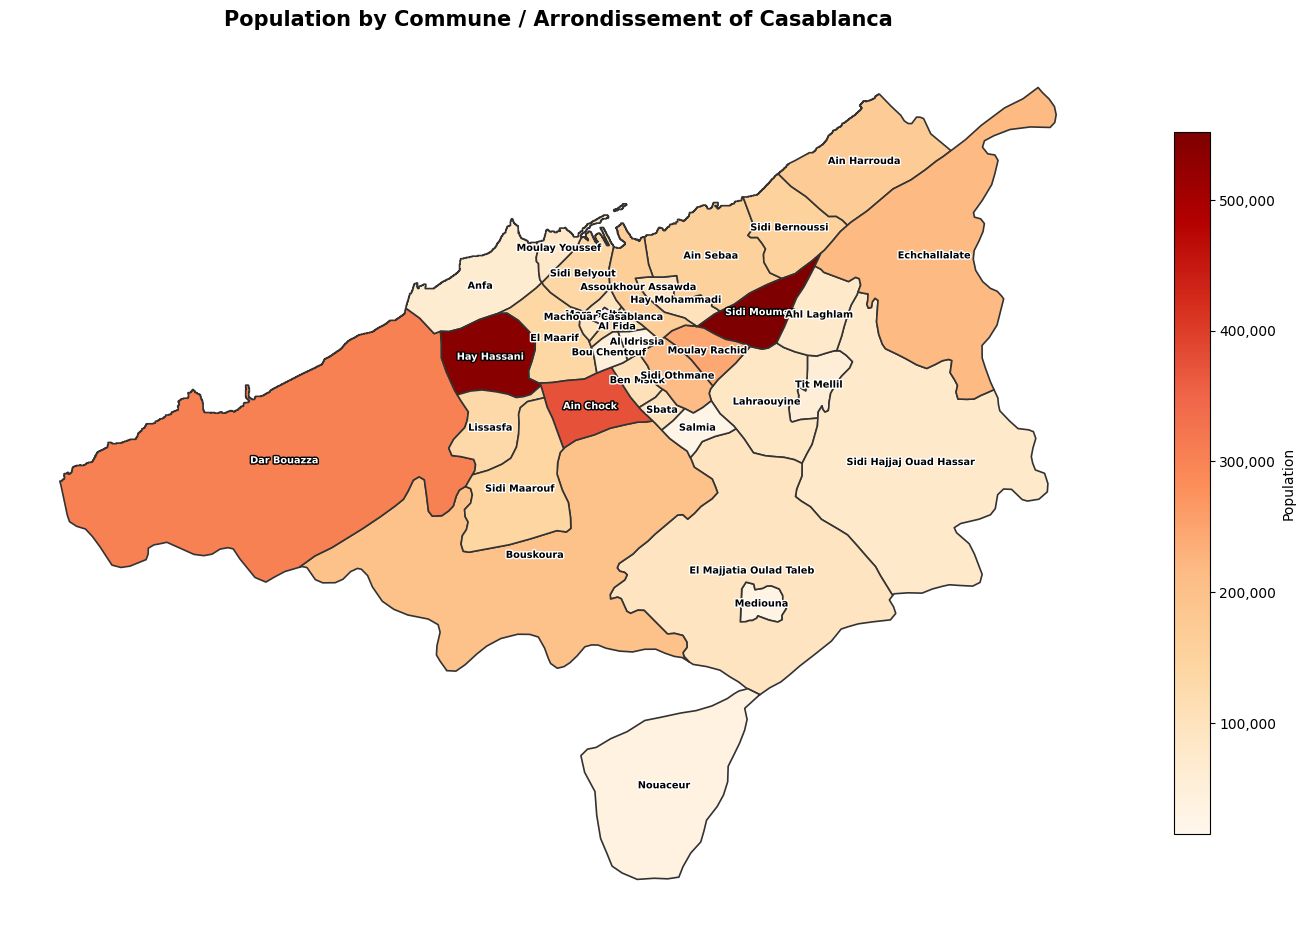

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12)) 

# Choropleth map of population by district
population.plot( 
    column="population", 
    cmap="OrRd", 
    linewidth=1.2,          
    edgecolor="#333333",    
    legend=True,
    legend_kwds={
        "label": "Population",
        "orientation": "vertical",
        "shrink": 0.6,
        "format": FuncFormatter(lambda x, _: f"{int(x):,}")  # comma-formatted ticks
    },
    ax=ax 
) 

# Add labels for each district
for idx, row in population.iterrows():
    pop = row["population"]
    name = row["commune"].title()  # capitalize each word

    # pick label color based on background darkness
    text_color = "white" if pop > 300_000 else "black"

    ax.annotate(
        name,
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=7,
        color=text_color,
        fontweight='bold',
        path_effects=[                          # white halo for contrast
            pe.withStroke(linewidth=2, foreground="white" if text_color == "black" else "black")
        ]
    )


ax.set_title(
    "Population by Commune / Arrondissement of Casablanca",
    fontsize=15,
    fontweight='bold',
    pad=16
)
ax.axis("off")

plt.tight_layout()
plt.savefig(f"{ANALYSIS_OUTPUT_DIR}/population_by_districts.png", dpi=300, bbox_inches='tight')
plt.show()

The population choropleth highlights where demand pressure is likely to be highest.

Areas with high density but limited nearby healthcare or weak transit connectivity are likely to experience disproportionate access burdens.

# Healthcare facilities per district

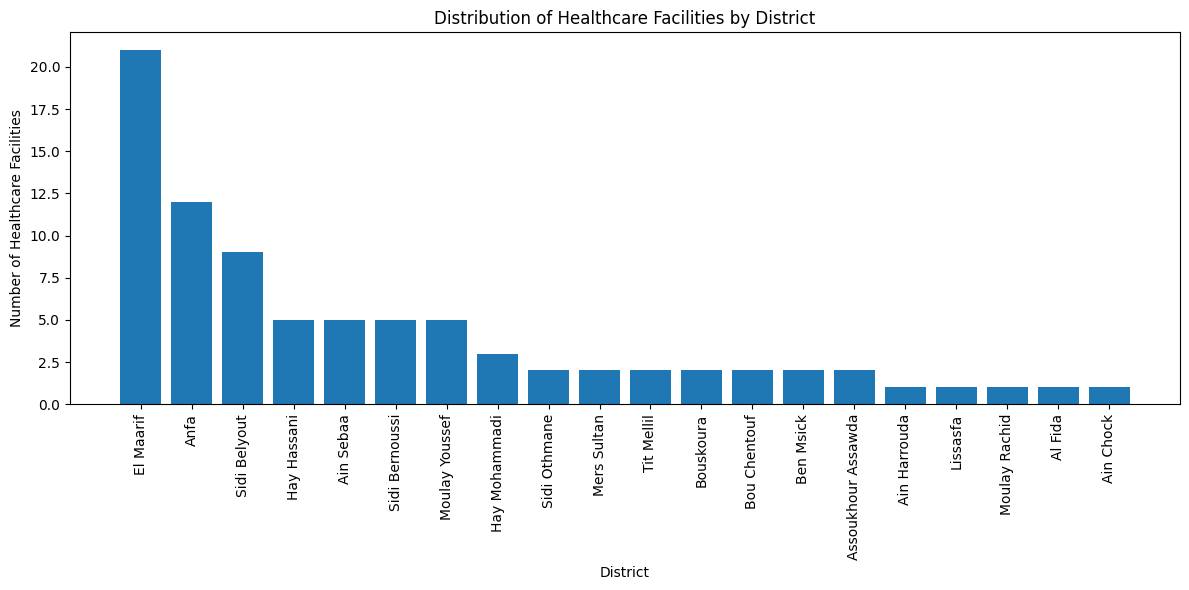

In [13]:
# Join healthcare facilities with districts to count number of facilities per district
healthcare_with_districts = gpd.sjoin(hospitals, districts, how="left", predicate="within")

# Count healthcare facilities per district
healthcare_counts = (
    healthcare_with_districts.groupby("district")
    .size()
    .reset_index(name="num_healthcare")
)

# Sort values in descending order
healthcare_counts = healthcare_counts.sort_values(by="num_healthcare", ascending=False)

# Plot Bar Chart of Healthcare Facilities by District
plt.figure(figsize=(12, 6))

plt.bar(healthcare_counts["district"], healthcare_counts["num_healthcare"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Healthcare Facilities")
plt.title("Distribution of Healthcare Facilities by District")

plt.tight_layout()
plt.show()

Healthcare facilities are unevenly distributed across districts.
A small number of central districts account for a disproportionately large share of facilities, while many districts have low observed supply.

# Transport Stops Per District

To explore the spatial distribution of public transport infrastructure, we computed the total number of stops (including both bus and tramway) within each district.

Each stop was assigned to a district using a spatial join, and counts were aggregated to identify areas with higher concentrations of transport services. The results are visualized in the bar chart below.

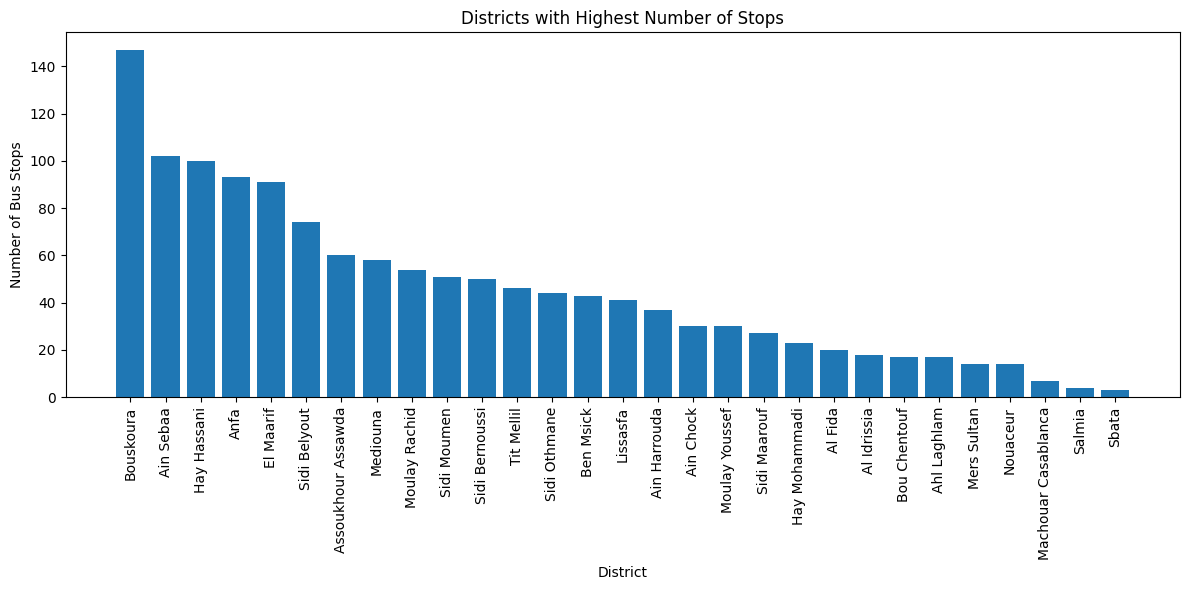

In [14]:
# Spatial join to assign each stop to a district
stops_with_districts = gpd.sjoin(stops, districts, how="left", predicate="within")

# Count stops per district
stops_count = stops_with_districts.groupby("district").size().reset_index(name="num_stops")

stops_count = stops_count.sort_values(by="num_stops", ascending=False)
plt.figure(figsize=(12, 6))

plt.bar(stops_count["district"], stops_count["num_stops"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Bus Stops")
plt.title("Districts with Highest Number of Stops")

plt.tight_layout()
plt.show()


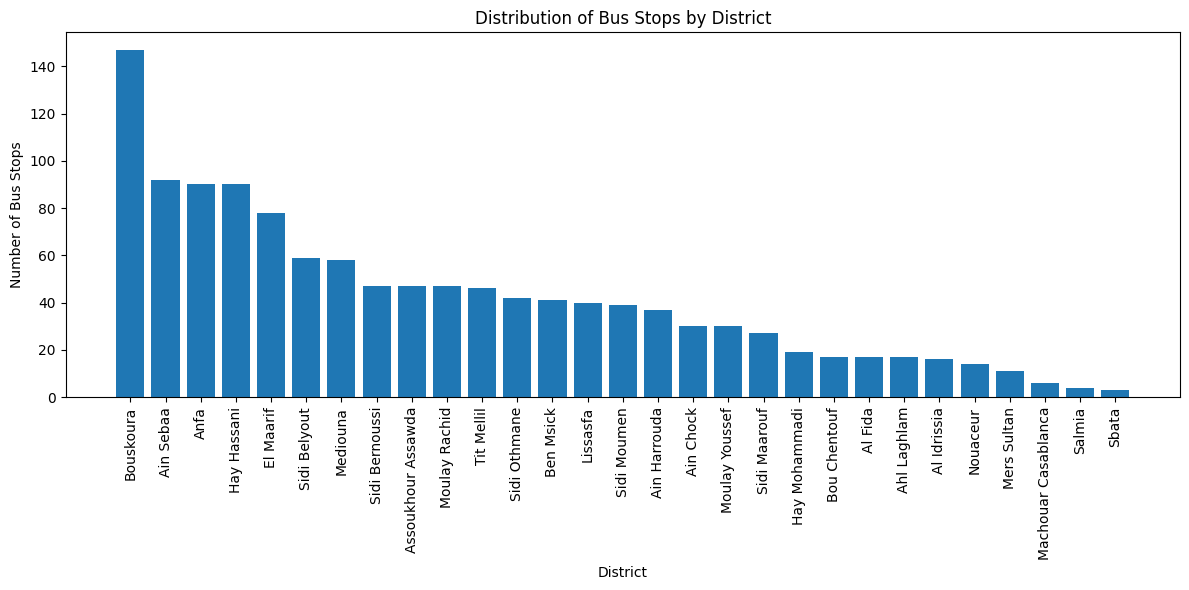

In [15]:
bus_stops = stops_with_districts[
    stops_with_districts["primary_mode"].isin(["casabus", "busway"])
]

bus_counts = (
    bus_stops.groupby("district")
    .size()
    .reset_index(name="num_bus_stops")
    .sort_values(by="num_bus_stops", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(bus_counts["district"], bus_counts["num_bus_stops"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Bus Stops")
plt.title("Distribution of Bus Stops by District")

plt.tight_layout()
plt.show()

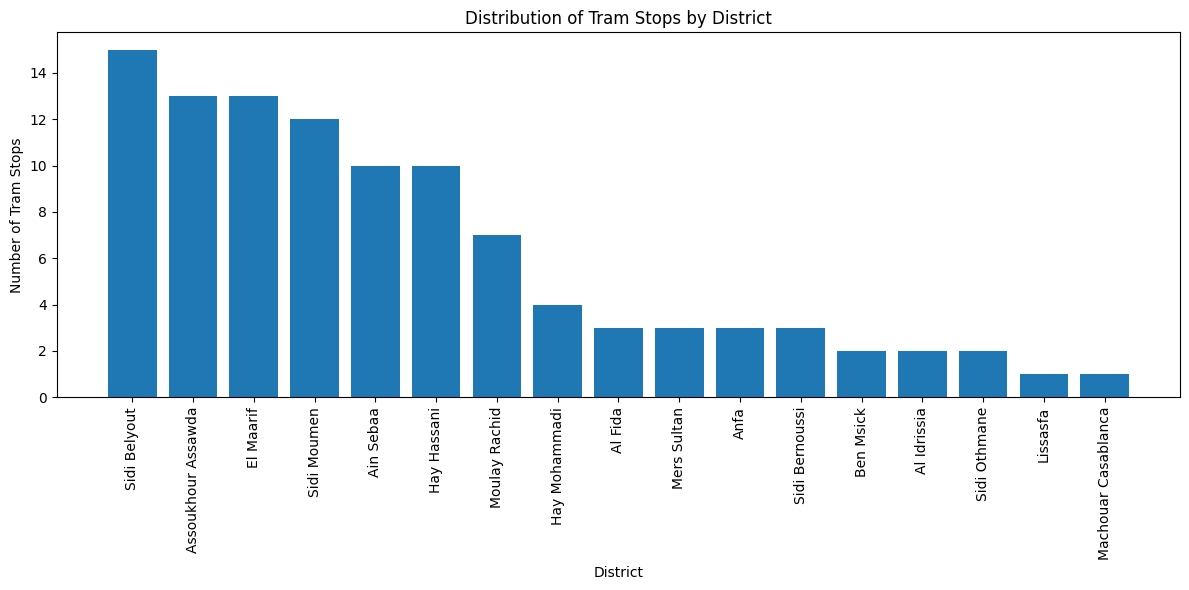

In [16]:
tram_stops = stops_with_districts[
    stops_with_districts["primary_mode"] == "tram"
]

tram_counts = (
    tram_stops.groupby("district")
    .size()
    .reset_index(name="num_tram_stops")
    .sort_values(by="num_tram_stops", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(tram_counts["district"], tram_counts["num_tram_stops"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Tram Stops")
plt.title("Distribution of Tram Stops by District")

plt.tight_layout()
plt.show()

District-level results show a strong concentration of stops in selected zones, with much weaker presence elsewhere.

By mode:
- Bus and busway stops drive most of the observed coverage.
- Tram stops are fewer and spatially concentrated, creating corridor-specific accessibility advantages.

This asymmetry matters because equitable healthcare access depends not only on facility placement but also on the distribution and diversity of transit connections.

# Population density and healthcare facilities distribution

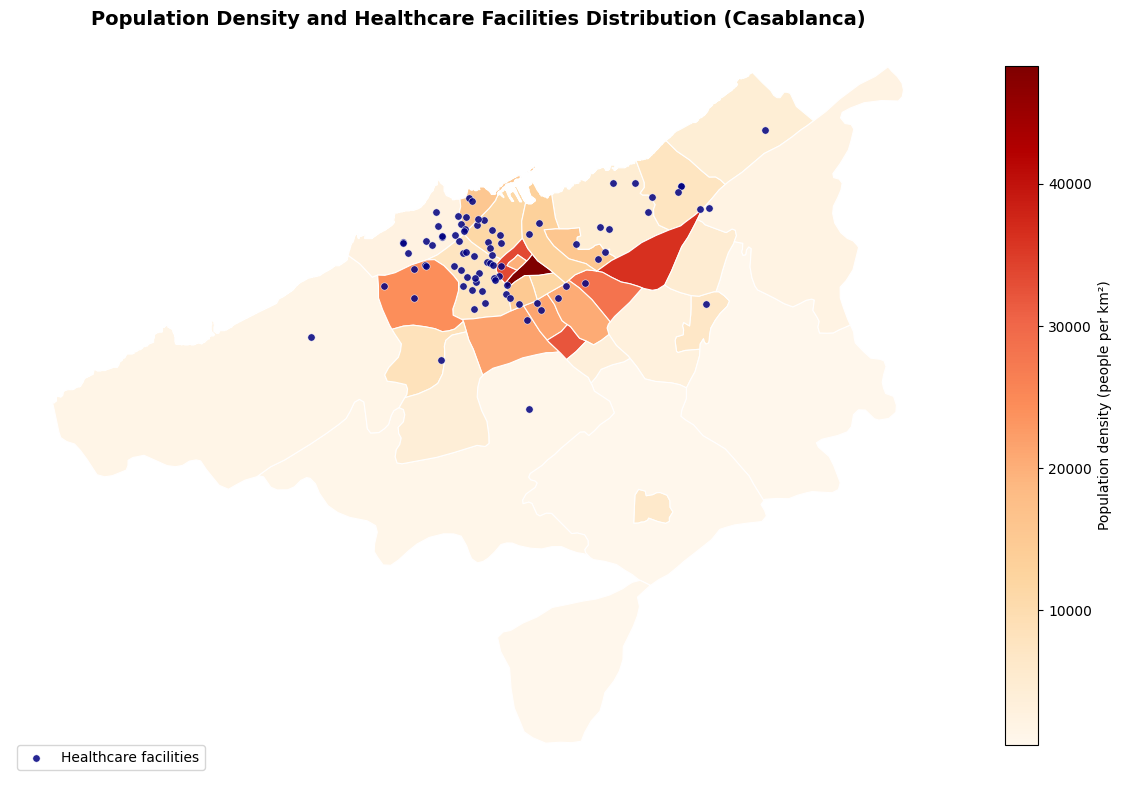

In [17]:
# Population density map + healthcare facilities overlay

# Ensure same CRS before plotting
pop_map = population.to_crs(hospitals.crs)

# Compute population density (people per km²)
pop_map["area_km2"] = pop_map.geometry.area / 1e6
pop_map["pop_density_km2"] = pop_map["population"] / pop_map["area_km2"]

fig, ax = plt.subplots(figsize=(12, 10))

# Choropleth: population density
pop_map.plot(
	column="pop_density_km2",
	cmap="OrRd",
	linewidth=0.8,
	edgecolor="white",
	legend=True,
	legend_kwds={"label": "Population density (people per km²)", "shrink": 0.7},
	ax=ax
)

# Overlay healthcare facilities
hospitals.plot(
	ax=ax,
	color="navy",
	markersize=28,
	alpha=0.85,
	edgecolor="white",
	linewidth=0.4,
	label="Healthcare facilities"
)

ax.set_title("Population Density and Healthcare Facilities Distribution (Casablanca)", fontsize=14, fontweight="bold")
ax.axis("off")
ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig(f"{ANALYSIS_OUTPUT_DIR}/population_density_healthcare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The overlay suggests a **mismatch between demand and service location** in Casablanca.

- Healthcare facilities appear concentrated in a limited set of central districts (notably **El Maarif**, **Anfa**, and **Sidi Belyout**).
- Several districts with large populations (e.g., **Sidi Moumen**, **Hay Hassani**, **Ain Chock**) show comparatively fewer facilities relative to their population size.
- Peripheral communes with lower density generally have sparse healthcare coverage, which may increase travel burdens.

Overall, the pattern indicates potential **spatial inequity** in healthcare access: areas with higher population pressure do not always coincide with higher facility availability.  

# 5. Methodology for Accessibility Assessment

This section operationalizes accessibility as a measurable spatial concept and links methods to the research question.

## 5.0 Methodological Scope, Assumptions, and Limitations

### Accessibility Definition Used in This Notebook
Accessibility is treated as the relative ease with which residents can reach healthcare services, approximated through spatial proximity and time-based indicators.

### Core Assumptions
- Spatial proximity is a meaningful first-order proxy for service access.
- Average speeds and waiting times represent typical urban travel conditions.
- District-level aggregation is appropriate for strategic planning insights.

### Limitations
- Straight-line or simplified network distances may differ from real route-constrained travel.
- Temporal effects (peak congestion, schedule reliability) are not fully modeled.
- Service quality and capacity differences across healthcare facilities are not explicitly weighted.

### DBSCAN in Underserved-Area Detection
Where clustering is applied, DBSCAN helps detect dense and sparse spatial patterns without predefining the number of clusters.
In this project context, sparse or low-density clusters can be interpreted as candidate underserved zones requiring closer planning attention.

# 6. Time-Based Accessibility Framework

### 6.1 Conceptual Model

The notebook extends pure distance metrics into a time-based model combining walking, waiting, and in-network movement.
This is more policy-relevant than fixed-radius methods because it better reflects real travel burdens experienced by residents.

### Fixed-Radius vs Distance/Time-Based Approaches
- Fixed-radius approaches are simple and interpretable but assume equal mobility and uniform network quality.
- Distance/time-based approaches capture heterogeneity in transport structure and are better suited for equity diagnostics in large cities like Casablanca.

In [18]:
# Constants for time calculations
WALKING_SPEED = 5  # km/h (average walking speed)
BUS_SPEED = 20  # km/h (average bus speed in urban areas)
WAIT_TIME = 10  # minutes (average waiting time for bus)
TRANSFER_TIME = 5  # minutes (time penalty for transfers)

# Convert speeds to m/min for calculations
WALKING_SPEED_M_MIN = (WALKING_SPEED * 1000) / 60  # meters per minute
BUS_SPEED_M_MIN = (BUS_SPEED * 1000) / 60  # meters per minute

print(f"Walking speed: {WALKING_SPEED} km/h ({WALKING_SPEED_M_MIN:.1f} m/min)")
print(f"Bus speed: {BUS_SPEED} km/h ({BUS_SPEED_M_MIN:.1f} m/min)")
print(f"Average wait time: {WAIT_TIME} minutes")
print(f"Transfer penalty: {TRANSFER_TIME} minutes")

Walking speed: 5 km/h (83.3 m/min)
Bus speed: 20 km/h (333.3 m/min)
Average wait time: 10 minutes
Transfer penalty: 5 minutes


In [19]:
def calculate_nearest_distances(origins_gdf, destinations_gdf, k=1):
    """
    Calculate distances from origins to k nearest destinations using spatial index.
    
    Parameters:
    -----------
    origins_gdf : GeoDataFrame
        Origin points (e.g., district centroids)
    destinations_gdf : GeoDataFrame
        Destination points (e.g., healthcare facilities, transport stops)
    k : int
        Number of nearest destinations to find
    
    Returns:
    --------
    distances : array
        Distances in meters to k nearest destinations
    indices : array
        Indices of k nearest destinations
    """
    # Extract coordinates
    origin_coords = np.array([(geom.x, geom.y) for geom in origins_gdf.geometry])
    dest_coords = np.array([(geom.x, geom.y) for geom in destinations_gdf.geometry])
    
    # Build spatial index
    tree = cKDTree(dest_coords)
    
    # Query k nearest neighbors
    distances, indices = tree.query(origin_coords, k=k)
    
    return distances, indices

In [20]:
# Calculate distance from district centroids to nearest transport stop
print("Calculating walking distances to nearest transport stops...")

# Use centroids as origin points
origin_points = gpd.GeoDataFrame(
    districts.drop('geometry', axis=1).copy(),
    geometry=districts['centroid'],
    crs=districts.crs
)

# Find nearest transport stop
distances_to_stop, stop_indices = calculate_nearest_distances(
    origin_points, stops, k=1
)

# Calculate walking time in minutes
districts['walk_dist_to_stop_m'] = distances_to_stop
districts['walk_time_to_stop_min'] = distances_to_stop / WALKING_SPEED_M_MIN

print(f"✓ Walking distances calculated")
print(f"\nWalking time to nearest stop statistics:")
print(districts['walk_time_to_stop_min'].describe())
print(f"\nDistricts with >15 min walk: {(districts['walk_time_to_stop_min'] > 15).sum()}")

Calculating walking distances to nearest transport stops...
✓ Walking distances calculated

Walking time to nearest stop statistics:
count    34.000000
mean      8.667594
std      12.782953
min       0.679355
25%       2.486544
50%       3.804231
75%       7.180483
max      55.618296
Name: walk_time_to_stop_min, dtype: float64

Districts with >15 min walk: 5


### 5.2 Calculate Travel Time from Transport Stops to Healthcare Facilities

In [21]:
# Build simplified transport network
print("Building transport network graph...")

# Create nodes from transport stops
G = nx.Graph()

# Add transport stop nodes
for idx, row in stops.iterrows():
    G.add_node(f"stop_{idx}", pos=(row.geometry.x, row.geometry.y), node_type='stop')

# Add healthcare nodes
for idx, row in hospitals.iterrows():
    G.add_node(f"health_{idx}", pos=(row.geometry.x, row.geometry.y), node_type='health')

print(f"✓ Network created with {G.number_of_nodes()} nodes")

# Connect nearby stops (simplified - assumes stops within 2km can be connected)
MAX_STOP_DISTANCE = 2000  # meters

stop_coords = np.array([(data['pos'][0], data['pos'][1]) 
                        for node, data in G.nodes(data=True) 
                        if data['node_type'] == 'stop'])
stop_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'stop']

if len(stop_coords) > 1:
    tree = cKDTree(stop_coords)
    pairs = tree.query_pairs(MAX_STOP_DISTANCE)
    
    for i, j in pairs:
        node_i = stop_nodes[i]
        node_j = stop_nodes[j]
        
        # Calculate distance
        pos_i = G.nodes[node_i]['pos']
        pos_j = G.nodes[node_j]['pos']
        distance = np.sqrt((pos_i[0] - pos_j[0])**2 + (pos_i[1] - pos_j[1])**2)
        
        # Calculate travel time (distance / bus speed)
        travel_time = distance / BUS_SPEED_M_MIN
        
        G.add_edge(node_i, node_j, weight=travel_time, distance=distance)

print(f"✓ Network connected with {G.number_of_edges()} edges")

Building transport network graph...
✓ Network created with 1547 nodes
✓ Network connected with 31325 edges


In [22]:
# Connect healthcare facilities to nearest stops (walking distance)
HEALTH_WALK_DISTANCE = 1000  # meters (max walking distance from stop to healthcare)

print("Connecting healthcare facilities to transport network...")

health_coords = np.array([(data['pos'][0], data['pos'][1]) 
                          for node, data in G.nodes(data=True) 
                          if data['node_type'] == 'health'])
health_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'health']

if len(health_coords) > 0 and len(stop_coords) > 0:
    tree = cKDTree(stop_coords)
    
    for i, health_node in enumerate(health_nodes):
        # Find nearest stops within walking distance
        health_coord = health_coords[i:i+1]
        indices = tree.query_ball_point(health_coord, HEALTH_WALK_DISTANCE)[0]
        
        for idx in indices[:5]:  # Connect to max 5 nearest stops
            stop_node = stop_nodes[idx]
            
            # Calculate walking time
            pos_h = G.nodes[health_node]['pos']
            pos_s = G.nodes[stop_node]['pos']
            distance = np.sqrt((pos_h[0] - pos_s[0])**2 + (pos_h[1] - pos_s[1])**2)
            walk_time = distance / WALKING_SPEED_M_MIN
            
            G.add_edge(health_node, stop_node, weight=walk_time, distance=distance, mode='walk')

print(f"✓ Healthcare facilities connected to transport network")
print(f"Final network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Connecting healthcare facilities to transport network...
✓ Healthcare facilities connected to transport network
Final network: 1547 nodes, 31737 edges


### 5.3 Calculate Total Travel Time for Each District

In [23]:
def calculate_total_travel_time(origin_gdf, stop_gdf, health_nodes, network, 
                                 walk_times, stop_indices):
    """
    Calculate total travel time from origins to nearest healthcare facility.
    
    Total time = Walking to stop + Waiting + Transit + Walking to healthcare
    """
    travel_times = []
    nearest_healthcare = []
    
    for i in range(len(origin_gdf)):
        # Get nearest stop
        nearest_stop_idx = stop_indices[i] if isinstance(stop_indices[i], (int, np.integer)) else stop_indices[i][0]
        stop_node = f"stop_{nearest_stop_idx}"
        
        # Calculate shortest path to all healthcare facilities
        min_time = float('inf')
        nearest_health = None
        
        for health_node in health_nodes:
            try:
                # Find shortest path in network
                path_length = nx.shortest_path_length(network, stop_node, health_node, weight='weight')
                
                # Total time = walk to stop + wait + transit + walk to healthcare
                total_time = walk_times[i] + WAIT_TIME + path_length
                
                if total_time < min_time:
                    min_time = total_time
                    nearest_health = health_node
            except nx.NetworkXNoPath:
                continue
        
        travel_times.append(min_time if min_time != float('inf') else np.nan)
        nearest_healthcare.append(nearest_health)
    
    return np.array(travel_times), nearest_healthcare

print("Calculating total travel times to healthcare facilities...")

Calculating total travel times to healthcare facilities...


In [24]:
# Get healthcare nodes
health_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'health']

# Calculate travel times
travel_times, nearest_health = calculate_total_travel_time(
    origin_points, 
    stops, 
    health_nodes, 
    G,
    districts['walk_time_to_stop_min'].values,
    stop_indices
)

districts['total_travel_time_min'] = travel_times
districts['nearest_healthcare'] = nearest_health

print("✓ Travel times calculated")
print(f"\nTravel time statistics:")
print(districts['total_travel_time_min'].describe())

# Count districts by accessibility level
print(f"\nAccessibility levels:")
print(f"  Excellent (<15 min): {(districts['total_travel_time_min'] < 15).sum()}")
print(f"  Good (15-30 min): {((districts['total_travel_time_min'] >= 15) & (districts['total_travel_time_min'] < 30)).sum()}")
print(f"  Moderate (30-45 min): {((districts['total_travel_time_min'] >= 30) & (districts['total_travel_time_min'] < 45)).sum()}")
print(f"  Poor (45-60 min): {((districts['total_travel_time_min'] >= 45) & (districts['total_travel_time_min'] < 60)).sum()}")
print(f"  Very Poor (>60 min): {(districts['total_travel_time_min'] >= 60).sum()}")

✓ Travel times calculated

Travel time statistics:
count    33.000000
mean     30.716735
std      19.177295
min      14.522700
25%      18.738668
50%      21.483477
75%      35.652982
max      89.904833
Name: total_travel_time_min, dtype: float64

Accessibility levels:
  Excellent (<15 min): 1
  Good (15-30 min): 22
  Moderate (30-45 min): 4
  Poor (45-60 min): 2
  Very Poor (>60 min): 4


### Interpretation: District Accessibility Gradients

The resulting travel-time classes provide a direct view of spatial inequality.
Districts with persistently high total travel times can be considered operationally underserved, especially where population concentration is high.

This is central to the capstone question because it links infrastructure geography to lived access burdens.

### 5.4 Create Accessibility Score

In [25]:
def calculate_accessibility_score(travel_time, max_time=60):
    """
    Calculate accessibility score (0-100) based on travel time.
    Score = 100 when travel_time = 0
    Score = 0 when travel_time >= max_time
    """
    if pd.isna(travel_time):
        return 0
    
    score = 100 * (1 - min(travel_time / max_time, 1))
    return max(0, score)

# Calculate accessibility scores
districts['accessibility_score'] = districts['total_travel_time_min'].apply(
    calculate_accessibility_score
)

# Categorize accessibility
def categorize_accessibility(score):
    if score >= 75:
        return 'Excellent'
    elif score >= 50:
        return 'Good'
    elif score >= 25:
        return 'Moderate'
    else:
        return 'Poor'

districts['accessibility_category'] = districts['accessibility_score'].apply(
    categorize_accessibility
)

print("✓ Accessibility scores calculated")
print(f"\nAccessibility score statistics:")
print(districts['accessibility_score'].describe())
print(f"\nAccessibility categories:")
print(districts['accessibility_category'].value_counts())

✓ Accessibility scores calculated

Accessibility score statistics:
count    34.000000
mean     50.116131
std      26.250018
min       0.000000
25%      38.638987
50%      62.578760
75%      68.638484
max      75.795499
Name: accessibility_score, dtype: float64

Accessibility categories:
accessibility_category
Good         22
Poor          7
Moderate      4
Excellent     1
Name: count, dtype: int64


### Technical Note: Nearest-Neighbor Search with `cKDTree`

`cKDTree` is used to efficiently compute nearest spatial matches between many points (e.g., healthcare sites and transit stops).
Compared with pairwise distance computation, this scales much better and is appropriate for city-wide analysis.

**Assumption:** straight-line distance is used as a proxy for actual route distance in this step.
This should be interpreted as an accessibility approximation rather than exact door-to-door travel distance.

In [26]:
# Project to metric CRS EPSG:32629 for accurate distance measurement 

hospitals_m = hospitals.to_crs(epsg=32629)
stops_m  = stops.to_crs(epsg=32629)

# Extract coordinates as numpy arrays
hospitals_coords = np.array([(geom.x, geom.y) for geom in hospitals_m.geometry])
stops_coords  = np.array([(geom.x, geom.y) for geom in stops_m.geometry])

# Build spatial index on stops
tree = cKDTree(stops_coords)

# Query: for each healthcare facility, find the nearest stop
distances, indices = tree.query(hospitals_coords, k=1)

hospitals['nearest_stop_dist_m'] = distances
hospitals['nearest_stop_name']   = stops.iloc[indices]['stop_name'].values
hospitals['nearest_stop_mode']   = stops.iloc[indices]['primary_mode'].values

print('Nearest stop computed for all healthcare facilities')
print(f'\nDistance to nearest stop (meters):')
print(hospitals['nearest_stop_dist_m'].describe().round(1))

Nearest stop computed for all healthcare facilities

Distance to nearest stop (meters):
count     84.0
mean     176.9
std      130.5
min       29.4
25%       93.7
50%      150.1
75%      225.8
max      945.9
Name: nearest_stop_dist_m, dtype: float64


## 6. Isochrone Analysis

Create time-based service areas around healthcare facilities

Creating isochrones for healthcare facilities...


C:\Users\afafb\AppData\Local\Temp\ipykernel_21416\3797034302.py:49: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=10)


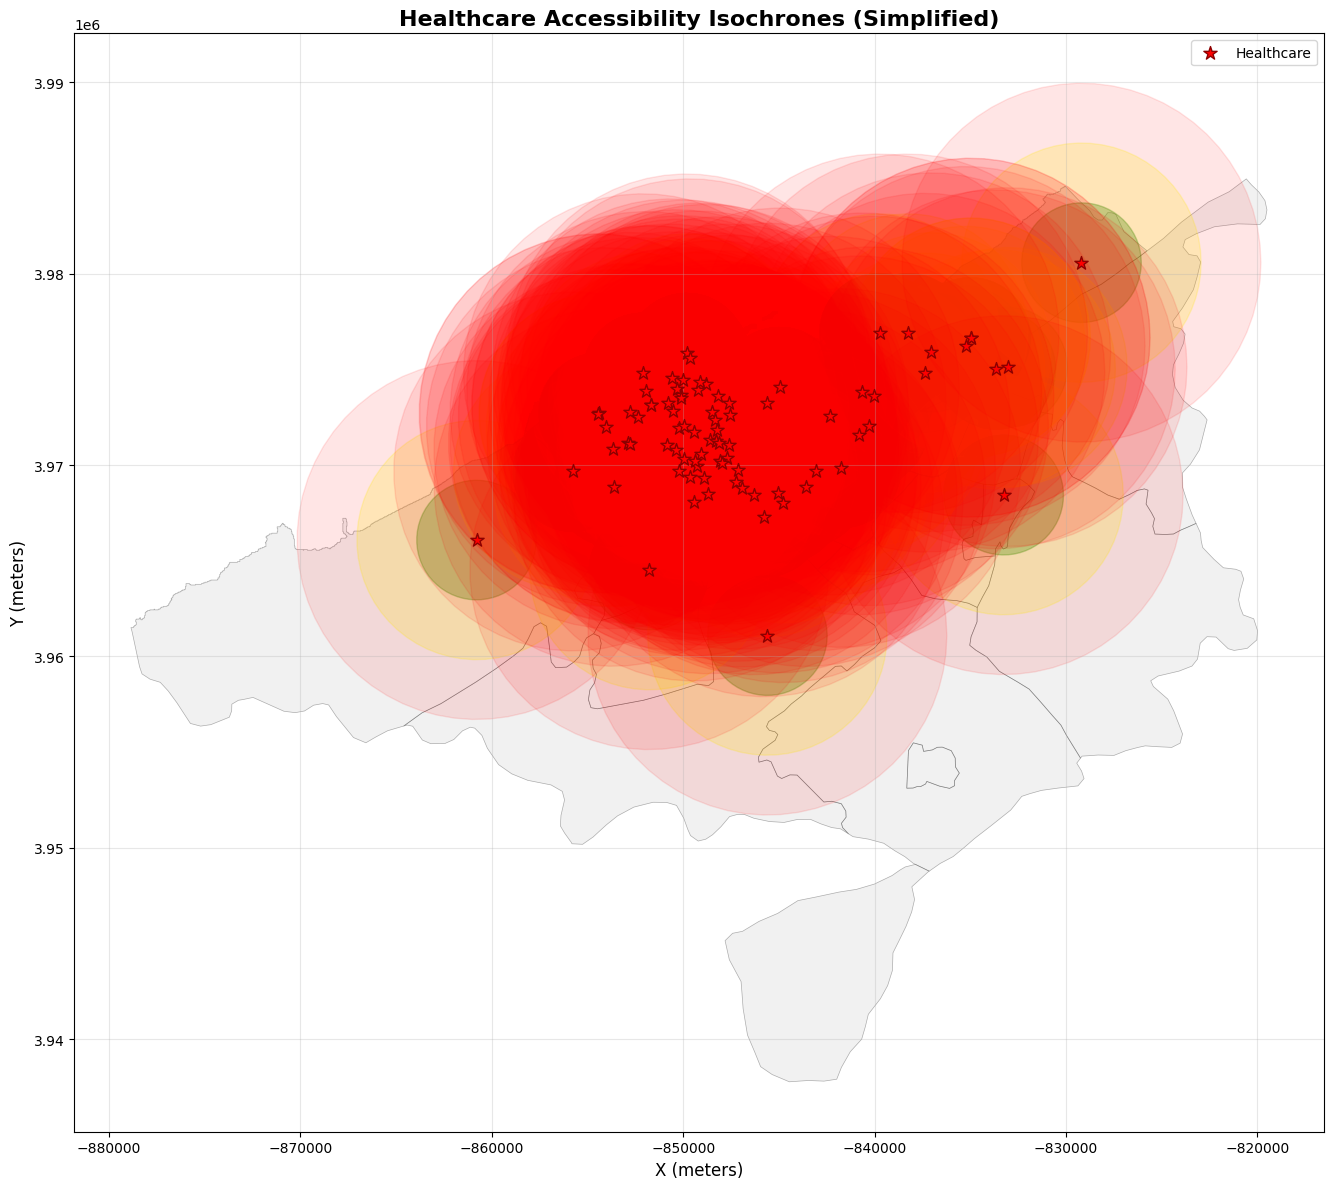

✓ Isochrone map created


In [27]:
def create_isochrones(center_point, travel_time_minutes, speed_m_min, num_points=64):
    """
    Create circular isochrone (simplified) around a point.
    In reality, isochrones follow the road network, but this provides a visualization.
    """
    # Calculate radius
    radius = travel_time_minutes * speed_m_min
    
    # Create circle
    angles = np.linspace(0, 2*np.pi, num_points)
    x = center_point.x + radius * np.cos(angles)
    y = center_point.y + radius * np.sin(angles)
    
    return Polygon(zip(x, y))

# Create isochrones for each healthcare facility
print("Creating isochrones for healthcare facilities...")

isochrone_times = [15, 30, 45]  # minutes
colors = ['green', 'yellow', 'red']
alphas = [0.3, 0.2, 0.1]

# Use combined speed (walking + transit average)
AVERAGE_SPEED = (WALKING_SPEED_M_MIN + BUS_SPEED_M_MIN) / 2

fig, ax = plt.subplots(figsize=(15, 12))

# Plot districts
districts.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5)

# Plot isochrones
for time, color, alpha in zip(isochrone_times, colors, alphas):
    isochrones = []
    for idx, row in hospitals.iterrows():
        isochrone = create_isochrones(row.geometry, time, AVERAGE_SPEED)
        isochrones.append(isochrone)
    
    isochrone_gdf = gpd.GeoDataFrame(geometry=isochrones, crs=hospitals.crs)
    isochrone_gdf.plot(ax=ax, color=color, alpha=alpha, edgecolor=color, 
                        linewidth=1, label=f'{time} min')

# Plot healthcare facilities
hospitals.plot(ax=ax, color='red', markersize=100, marker='*', 
                     edgecolor='darkred', linewidth=1, label='Healthcare', zorder=5)

ax.set_title('Healthcare Accessibility Isochrones (Simplified)', fontsize=16, fontweight='bold')
ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Isochrone map created")

## 7. Accessibility Visualization

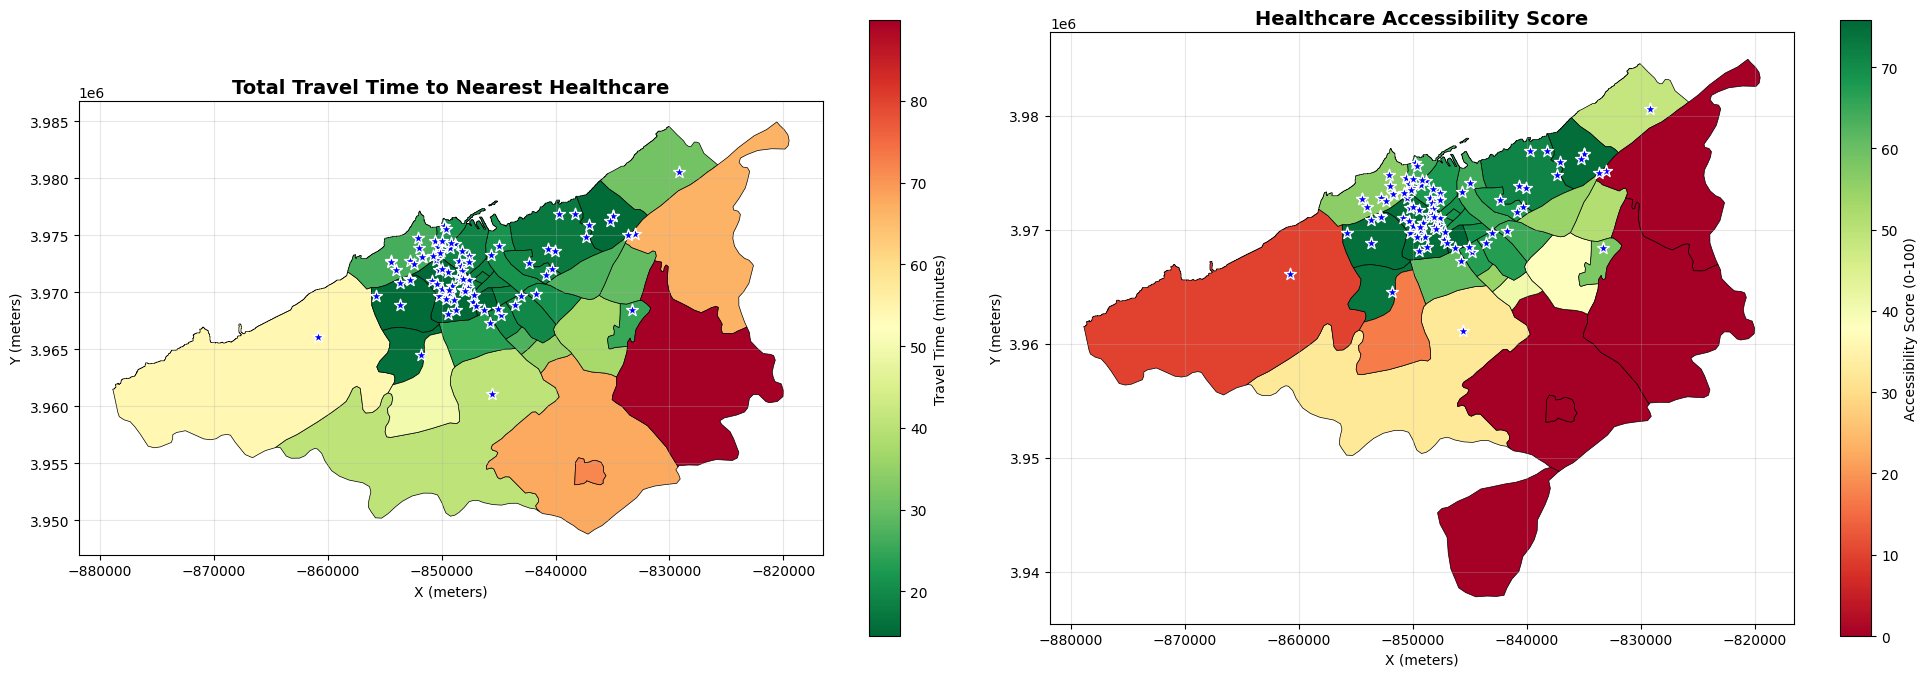

✓ Accessibility maps created


In [28]:
# Create accessibility choropleth map
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Map 1: Travel time
districts.plot(column='total_travel_time_min', ax=axes[0], legend=True, 
                    cmap='RdYlGn_r', edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Travel Time (minutes)', 'shrink': 0.8})
hospitals.plot(ax=axes[0], color='blue', markersize=80, marker='*', 
                     edgecolor='white', linewidth=1, zorder=5)
axes[0].set_title('Total Travel Time to Nearest Healthcare', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X (meters)')
axes[0].set_ylabel('Y (meters)')
axes[0].grid(True, alpha=0.3)

# Map 2: Accessibility score
districts.plot(column='accessibility_score', ax=axes[1], legend=True, 
                    cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Accessibility Score (0-100)', 'shrink': 0.8})
hospitals.plot(ax=axes[1], color='blue', markersize=80, marker='*', 
                     edgecolor='white', linewidth=1, zorder=5)
axes[1].set_title('Healthcare Accessibility Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X (meters)')
axes[1].set_ylabel('Y (meters)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Accessibility maps created")

### Interpretation: Spatial Pattern of Accessibility Scores

The dual maps compare raw travel burden and normalized accessibility scores.
A recurring center-periphery contrast indicates that residents in outer districts may require more time to reach care, even when city-wide averages appear acceptable.

This visual evidence supports targeted interventions rather than uniform city-wide policy responses.

## 8. Equity Analysis

Analyze accessibility in relation to population

In [29]:
# Population-weighted accessibility
if 'population' in districts.columns:
    # Calculate population with poor accessibility
    poor_access = districts['accessibility_score'] < 50
    pop_poor_access = districts[poor_access]['population'].sum()
    total_pop = districts['population'].sum()
    
    print("=" * 60)
    print("EQUITY ANALYSIS")
    print("=" * 60)
    print(f"\nTotal population: {total_pop:,.0f}")
    print(f"Population with poor accessibility (<50 score): {pop_poor_access:,.0f}")
    print(f"Percentage affected: {100 * pop_poor_access / total_pop:.1f}%")
    
    # Calculate weighted average travel time
    weighted_travel_time = np.average(
        districts['total_travel_time_min'].fillna(60),
        weights=districts['population']
    )
    print(f"\nPopulation-weighted average travel time: {weighted_travel_time:.1f} minutes")
    
    # Scatter plot: Population vs Accessibility
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(districts['population'], 
                         districts['accessibility_score'],
                         c=districts['accessibility_score'],
                         s=districts['area_km2']*10,
                         cmap='RdYlGn', alpha=0.6, edgecolor='black', linewidth=0.5)
    
    ax.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, 
               label='Poor Accessibility Threshold')
    
    ax.set_xlabel('Population', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accessibility Score', fontsize=12, fontweight='bold')
    ax.set_title('Population vs Healthcare Accessibility\n(bubble size = district area)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Accessibility Score', fontsize=10)
    
    plt.tight_layout()
    plt.show()

### Interpretation: Equity Implications

Population-weighted indicators translate accessibility into social impact.
Even moderate geographic disparities can affect a large number of residents when they occur in high-population districts.

This section therefore moves from spatial description to distributive equity: who is most affected and where.

C:\Users\afafb\AppData\Local\Temp\ipykernel_21416\2060902128.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(data_to_plot, labels=['Walk to Stop', 'Wait Time', 'Transit Time'],


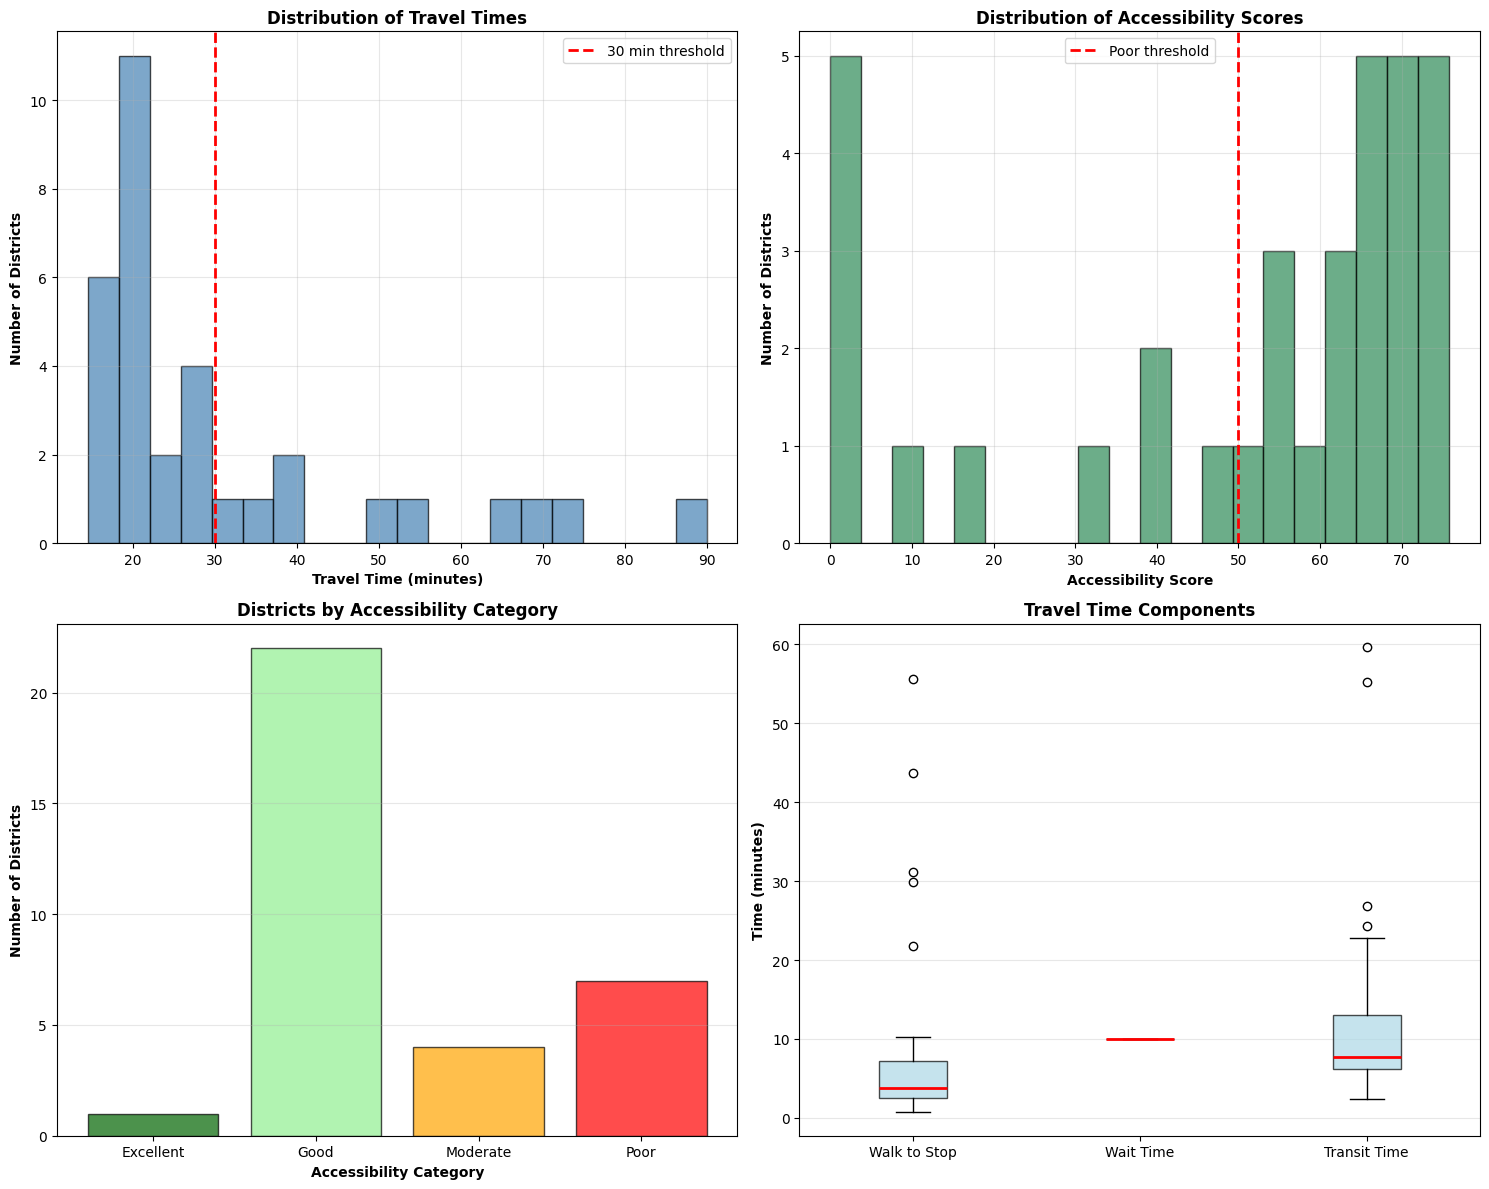

✓ Statistical visualizations created


In [30]:
# Distribution of travel times
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram: Travel times
axes[0, 0].hist(districts['total_travel_time_min'].dropna(), bins=20, 
                color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=30, color='red', linestyle='--', linewidth=2, label='30 min threshold')
axes[0, 0].set_xlabel('Travel Time (minutes)', fontweight='bold')
axes[0, 0].set_ylabel('Number of Districts', fontweight='bold')
axes[0, 0].set_title('Distribution of Travel Times', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Histogram: Accessibility scores
axes[0, 1].hist(districts['accessibility_score'].dropna(), bins=20, 
                color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Poor threshold')
axes[0, 1].set_xlabel('Accessibility Score', fontweight='bold')
axes[0, 1].set_ylabel('Number of Districts', fontweight='bold')
axes[0, 1].set_title('Distribution of Accessibility Scores', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bar chart: Accessibility categories
category_counts = districts['accessibility_category'].value_counts()
category_order = ['Excellent', 'Good', 'Moderate', 'Poor']
category_counts = category_counts.reindex(category_order, fill_value=0)
colors_cat = ['darkgreen', 'lightgreen', 'orange', 'red']

axes[1, 0].bar(category_counts.index, category_counts.values, color=colors_cat, 
               edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Accessibility Category', fontweight='bold')
axes[1, 0].set_ylabel('Number of Districts', fontweight='bold')
axes[1, 0].set_title('Districts by Accessibility Category', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Box plot: Travel time components
walk_times = districts['walk_time_to_stop_min'].dropna()
transit_times = (districts['total_travel_time_min'] - 
                 districts['walk_time_to_stop_min'] - WAIT_TIME).dropna()

data_to_plot = [walk_times, [WAIT_TIME]*len(districts), transit_times]
axes[1, 1].boxplot(data_to_plot, labels=['Walk to Stop', 'Wait Time', 'Transit Time'],
                   patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Time (minutes)', fontweight='bold')
axes[1, 1].set_title('Travel Time Components', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Statistical visualizations created")

## 10. Summary Statistics and Rankings

In [31]:
# Create summary table
district_col = 'district' if 'district' in districts.columns else 'commune'

summary_cols = [district_col, 'population', 'area_km2', 'pop_density',
                'walk_time_to_stop_min', 'total_travel_time_min', 
                'accessibility_score', 'accessibility_category']

summary_cols = [col for col in summary_cols if col in districts.columns]

summary_df = districts[summary_cols].copy()
summary_df = summary_df.sort_values('accessibility_score', ascending=False)

print("=" * 80)
print("DISTRICT ACCESSIBILITY RANKINGS")
print("=" * 80)
print("\nTop 10 Most Accessible Districts:")
print("=" * 80)
display(summary_df.head(10))

print("\n" + "=" * 80)
print("Bottom 10 Least Accessible Districts:")
print("=" * 80)
display(summary_df.tail(10))

DISTRICT ACCESSIBILITY RANKINGS

Top 10 Most Accessible Districts:


,district,area_km2,walk_time_to_stop_min,total_travel_time_min,accessibility_score,accessibility_category
13,Bou Chentouf,3.311645,2.184280,14.522700,75.795499,Excellent
14,El Maarif,18.420424,2.468223,15.098789,74.835351,Good
27,Sidi Bernoussi,20.686249,2.774786,15.179511,74.700816,Good
15,Hay Hassani,22.162089,2.641603,15.275107,74.541489,Good
17,Lissasfa,15.464799,0.679355,15.983872,73.360213,Good
7,Ain Sebaa,32.532248,2.590407,17.289633,71.183945,Good
9,Al Idrissia,2.590321,2.278939,18.421748,69.297086,Good
20,Mers Sultan,2.932811,1.744182,18.604375,68.992708,Good
18,Machouar Casablanca,0.748357,1.027908,18.738668,68.768886,Good
8,Al Fida,2.606387,1.380240,19.051633,68.247278,Good



Bottom 10 Least Accessible Districts:


,district,area_km2,walk_time_to_stop_min,total_travel_time_min,accessibility_score,accessibility_category
24,Salmia,6.894062,6.383247,35.652982,40.578363,Moderate
3,Mediouna,29.032640,4.468825,37.204483,37.992528,Moderate
0,Bouskoura,165.287114,3.671637,40.524283,32.459529,Moderate
28,Sidi Maarouf,34.997247,21.744128,49.763953,17.060079,Poor
1,Bouskoura,216.995776,29.858507,53.993817,10.010305,Poor
23,Nouaceur,69.090937,31.171395,NaN,0.000000,Poor
19,Mediouna,4.950054,2.247817,71.916709,0.000000,Poor
2,Mediouna,135.233337,2.541509,67.773452,0.000000,Poor
32,Tit Mellil,98.914770,43.733012,66.426314,0.000000,Poor
33,Tit Mellil,140.820345,55.618296,89.904833,0.000000,Poor


In [32]:
# Overall statistics
print("=" * 80)
print("OVERALL ACCESSIBILITY STATISTICS")
print("=" * 80)

print(f"\nStudy Area:")
print(f"  Total districts: {len(districts)}")
print(f"  Total area: {districts['area_km2'].sum():.2f} km²")
if 'population' in districts.columns:
    print(f"  Total population: {districts['population'].sum():,.0f}")
    print(f"  Average population density: {districts['pop_density'].mean():.1f} per km²")

print(f"\nHealthcare Infrastructure:")
print(f"  Healthcare facilities: {len(hospitals)}")
print(f"  Transport stops: {len(hospitals)}")

print(f"\nAccessibility Metrics:")
print(f"  Average travel time: {districts['total_travel_time_min'].mean():.1f} minutes")
print(f"  Median travel time: {districts['total_travel_time_min'].median():.1f} minutes")
print(f"  Average accessibility score: {districts['accessibility_score'].mean():.1f}")
print(f"  Districts with excellent access (score ≥75): {(districts['accessibility_score'] >= 75).sum()}")
print(f"  Districts with poor access (score <50): {(districts['accessibility_score'] < 50).sum()}")

if 'population' in districts.columns:
    print(f"\nPopulation-Weighted Metrics:")
    print(f"  Weighted avg travel time: {weighted_travel_time:.1f} minutes")
    print(f"  Population with poor access: {pop_poor_access:,.0f} ({100*pop_poor_access/total_pop:.1f}%)")

OVERALL ACCESSIBILITY STATISTICS

Study Area:
  Total districts: 34
  Total area: 1208.62 km²

Healthcare Infrastructure:
  Healthcare facilities: 84
  Transport stops: 84

Accessibility Metrics:
  Average travel time: 30.7 minutes
  Median travel time: 21.5 minutes
  Average accessibility score: 50.1
  Districts with excellent access (score ≥75): 1
  Districts with poor access (score <50): 11


## 11. Final Insights and Recommendations

### Key Findings
- Healthcare and transport services are not evenly distributed across Casablanca.
- Accessibility varies significantly by district, with a visible center-periphery gradient.
- Population-weighted metrics indicate that accessibility deficits can affect substantial resident groups.

### Likely Underserved Areas
Districts combining high travel times, lower accessibility scores, and large populations should be treated as priority underserved zones.
Where clustering outputs indicate sparse service patterns, those zones warrant targeted validation and intervention.

### Practical Planning Recommendations
1. Prioritize new primary-care facilities in high-population districts with poor accessibility scores.
2. Improve feeder transit and stop density around low-access districts and peripheral communes.
3. Increase multimodal integration (bus-tram connections) in districts with limited route diversity.
4. Use periodic re-evaluation with updated population and service data to monitor equity improvements.

### Conclusion
The evidence indicates that healthcare accessibility in Casablanca is spatially unequal.
A planning strategy that jointly optimizes facility placement and transport connectivity is essential to reduce underserved conditions and improve urban health equity.